# Computer Exercise 15.29 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: §15.29 Sequential Decision Making — *Block-Partitioned Trunk & Reassembly Interference*
> **풀이 일자**: Day 96
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **Problem 1.** Day 95 (§15.28 Problem 1) reassembled the +CNRT stack with *component-local*
> hyperparameters $(\sigma_{0,c}, \eta_c)$ but kept a **shared trunk**
> $W_1 \in \mathbb{R}^{H \times d_{\text{state}}}$; the trunk therefore receives an averaged
> (or summed) gradient from all four heads (Noisy / Cramér / EMA / Twin), which mixes their
> update directions. The Day 95 reassembly returned $R^{\text{reassembly}}$ that failed to
> overturn the Day 93 combined $-0.288$ marginal decisively.
> **Modify the architecture so that each component owns a disjoint slice** of the trunk row
> block: partition $W_1$ as $W_1 = [W_1^{(N)};\, W_1^{(C)};\, W_1^{(E)};\, W_1^{(T)}]$ with
> row-slices $H_N + H_C + H_E + H_T = H$, and route each component's head onto only its own
> slice's activations. Train 3 seeds $\times$ 400 steps on the same chain MDP as Day 95;
> deploy at softmax $\tau=0.10$. Measure (i) block-partitioned reassembly return
> $R^{\text{bp}}$; (ii) $\Delta_{\text{bp}} = R^{\text{bp}} - R^{\text{shared}}$ over 3 seeds;
> (iii) per-slice utilisation $\|W_1^{(c)}\|_F^2 / \|W_1\|_F^2$ after training.

### 한국어 풀이용 정리
Day 95 P1 의 재조립 스택은 공유 트렁크 $W_1$ 위에 4 개 성분 헤드를 얹었기 때문에 트렁크가
받는 gradient 는 4 개 방향의 평균이다. 이 **성분 간 간섭**을 제거하기 위해 $W_1$ 을 성분별로
**행 블록 분할** (block partition) 하고 각 헤드를 자기 블록의 활성값에만 붙인다. 400 step,
3 시드 학습 후 softmax $\tau=0.10$ 배포로 return 을 측정하고, 공유 트렁크 baseline (Day 95
P1 스타일) 과의 gap $\Delta_{\text{bp}}$ 를 낸다.


## 2. 수학적 배경

### 2.1 공유 트렁크의 gradient 평균화 근사
공유 트렁크가 성분 헤드 $c \in \mathcal{C}=\{N, C, E, T\}$ 각각으로부터 gradient
$g_1^{(c)}$ 를 받으면 미니배치 갱신은

$$
W_1 \leftarrow W_1 - \eta \, \sum_{c \in \mathcal{C}} g_1^{(c)}
$$

이며, 이는 헤드별 objective $\mathcal{L}_c$ 를 균일 가중 합한 objective 의 stochastic
gradient descent 이다. Cramér CDF-정합, KL cross-entropy, EMA whitening 이 서로 다른
직교하지 않는 방향으로 $W_1$ 을 밀 때 **평균 gradient 는 어느 방향으로도 유효한 개선이
아닐 수** 있다.

### 2.2 Block partition 근사
$W_1 \in \mathbb{R}^{H \times d}$ 를 성분별로 행 블록 분할

$$
W_1 \;=\; \begin{bmatrix} W_1^{(N)} \\ W_1^{(C)} \\ W_1^{(E)} \\ W_1^{(T)} \end{bmatrix},
\qquad H = H_N + H_C + H_E + H_T
$$

하고, 헤드 $c$ 는 자기 블록의 활성 $h^{(c)} = \tanh(W_1^{(c)} x) \in \mathbb{R}^{H_c}$ 만
소비한다. 이 경우 $W_1^{(c)}$ 는 오직 헤드 $c$ 의 gradient 만 받는다:

$$
\boxed{\;\nabla_{W_1^{(c)}} \mathcal{L}_c \perp\!\!\!\perp \nabla_{W_1^{(c')}} \mathcal{L}_{c'}
  \;\text{ for } c \neq c'.\;}
$$

이 **직교화** 는 성분 간 gradient 간섭을 구조적으로 제거하지만, 표현력을 성분별로 $H_c$ 로
제한한다.

### 2.3 재조립 return 지표
Deployment 에서 각 seed 는 60 에피소드 softmax($\tau=0.10$) rollout 을 수행하고 return
평균을 낸다:

$$
R^{\text{bp}} \;=\; \frac{1}{3} \sum_{s=1}^{3} \bar R_s^{\text{bp}}, \qquad
\Delta_{\text{bp}} \;=\; R^{\text{bp}} - R^{\text{shared}}.
$$

$\Delta_{\text{bp}} > 0$ 이면 block partition 이 gradient 간섭을 실제로 제거해 이득을
가져왔음을 시사.


## 3. 풀이 흐름

1. 5-state chain MDP 환경 정의 ($p_{\text{train}}=0.10$ slip).
2. 공유 트렁크 스택 (`SharedTrunkStack`, block_partition=False) — Day 95 P1 스타일.
3. Block partition 스택 (block_partition=True) — $W_1$ 을 $H_N + H_C + H_E + H_T = H$ 로
   행 블록 분할, 각 헤드가 자기 블록만 사용.
4. 시드 96101–96103 각각 400 step 학습, softmax $\tau=0.10$ 로 60 에피소드 배포.
5. 표: seed × {shared, block-partition} return, seed 평균/표준편차, $\Delta_{\text{bp}}$.
6. 그림 1: seed 별 return bar chart. 그림 2: 슬라이스별 utilisation bar chart.
7. 결과 해석: 간섭 제거의 실효성, 표현력 제약 trade-off, Day 95 combined 대비 판정.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.4f}")
plt.rcParams.update({"figure.dpi": 96, "font.size": 10})
np.set_printoptions(precision=4, suppress=True)

# ---------------------------------------------------------------
# Chain MDP: 5 states, actions {left, right}, slip flips direction.
# Reward: +1 at state 4 (rightmost), else 0. Episode length 20.
# ---------------------------------------------------------------
N_STATES = 5
GAMMA = 0.95
EPISODE_LEN = 20
P_SLIP = 0.10

def env_step(s, a, p_slip, rng):
    if rng.random() < p_slip:
        a = 1 - a
    ns = s + 1 if a == 1 else s - 1
    ns = max(0, min(N_STATES - 1, ns))
    r = 1.0 if ns == N_STATES - 1 else 0.0
    return ns, r

def one_hot(s, n=N_STATES):
    v = np.zeros(n); v[s] = 1.0; return v


In [2]:

class SharedTrunkStack:
    def __init__(self, H, seed, block_partition=False):
        rng = np.random.default_rng(seed)
        self.H = H
        self.rng = rng
        self.block_partition = block_partition
        # component-local (sigma0, eta) cells from Day 94 P1
        self.cells = {
            "N": (0.1, 0.02),
            "C": (0.3, 0.05),
            "E": (0.3, 0.02),
            "T": (0.1, 0.05),
        }
        if block_partition:
            base = H // 4
            self.blocks = {"N": base, "C": base, "E": base, "T": H - 3 * base}
        else:
            self.blocks = {c: H for c in self.cells}
        med_sigma = float(np.median([s0 for (s0, _) in self.cells.values()]))
        self.W1 = rng.normal(0, med_sigma, size=(H, N_STATES))
        self.heads = {}
        for c, (s0, _) in self.cells.items():
            Hc = self.blocks[c]
            self.heads[c] = rng.normal(0, s0, size=(2, Hc))
        # EMA whitening state (over full trunk activation)
        self.ema_mu = np.zeros(H)
        self.ema_var = np.ones(H)
        self.ema_beta = 0.90

    def _slice_bounds(self, c):
        starts = {"N": 0}
        starts["C"] = self.blocks["N"]
        starts["E"] = self.blocks["N"] + self.blocks["C"]
        starts["T"] = starts["E"] + self.blocks["E"]
        st = starts[c]; Hc = self.blocks[c]
        return st, Hc

    def _slice(self, c, h):
        if not self.block_partition:
            return h
        st, Hc = self._slice_bounds(c)
        return h[st:st + Hc]

    def features(self, s):
        x = one_hot(s)
        pre = self.W1 @ x
        h = np.tanh(pre)
        # running EMA update
        self.ema_mu = self.ema_beta * self.ema_mu + (1 - self.ema_beta) * h
        self.ema_var = (self.ema_beta * self.ema_var
                        + (1 - self.ema_beta) * (h - self.ema_mu) ** 2)
        return x, pre, h

    def _head_out(self, c, h_full):
        h_c = self._slice(c, h_full)
        if c == "E":
            mu = self._slice(c, self.ema_mu)
            var = self._slice(c, self.ema_var)
            h_c = (h_c - mu) / np.sqrt(var + 1e-6)
        return self.heads[c] @ h_c, h_c

    def q_values(self, s):
        x, pre, h = self.features(s)
        q_agg = np.zeros(2)
        for c in self.cells:
            q_c, _ = self._head_out(c, h)
            w = 0.5 if c == "T" else 1.0
            q_agg += w * q_c
        q_agg /= 3.5
        return q_agg, x, pre, h

    def act(self, s, tau=0.10):
        q, *_ = self.q_values(s)
        z = q / max(tau, 1e-6)
        z -= z.max()
        p = np.exp(z) / np.exp(z).sum()
        return int(self.rng.choice(2, p=p))

    def update(self, s, a, r, sp):
        q_s, x, pre, h = self.q_values(s)
        with_next, *_ = self.q_values(sp)
        target = r + GAMMA * with_next.max()
        for c, (_, eta) in self.cells.items():
            q_c, h_c = self._head_out(c, h)
            td = target - q_c[a]
            grad_head = np.zeros_like(self.heads[c])
            grad_head[a] = -td * h_c
            head_a = self.heads[c][a]
            if self.block_partition:
                st, Hc = self._slice_bounds(c)
                pre_c = pre[st:st + Hc]
                dh = (1 - np.tanh(pre_c) ** 2)
                grad_trunk_c = -td * (head_a * dh)[:, None] * x[None, :]
                self.W1[st:st + Hc] -= eta * grad_trunk_c
            else:
                dh = (1 - np.tanh(pre) ** 2)
                grad_trunk = -td * (head_a * dh)[:, None] * x[None, :]
                self.W1 -= eta * grad_trunk
            self.heads[c] -= eta * grad_head


In [3]:

def train_and_deploy(seed, block_partition, H=32, T=400, n_deploy=60, tau=0.10):
    stack = SharedTrunkStack(H=H, seed=seed, block_partition=block_partition)
    rng = np.random.default_rng(seed + 999)
    for t in range(T):
        s = rng.integers(0, N_STATES)
        a = stack.act(s, tau=tau)
        sp, r = env_step(s, a, P_SLIP, rng)
        stack.update(s, a, r, sp)
    deploy_rng = np.random.default_rng(seed + 12345)
    returns = []
    for ep in range(n_deploy):
        s = deploy_rng.integers(0, N_STATES)
        G = 0.0; disc = 1.0
        for _ in range(EPISODE_LEN):
            a = stack.act(s, tau=tau)
            sp, r = env_step(s, a, P_SLIP, deploy_rng)
            G += disc * r; disc *= GAMMA; s = sp
        returns.append(G)
    return float(np.mean(returns)), stack

SEEDS = [96101, 96102, 96103]
rows = []
utilisations = []
for seed in SEEDS:
    R_shared, _  = train_and_deploy(seed, block_partition=False)
    R_bp, stack_bp = train_and_deploy(seed, block_partition=True)
    rows.append({"seed": seed, "R_shared": R_shared, "R_bp": R_bp,
                 "Delta_bp": R_bp - R_shared})
    total = np.sum(stack_bp.W1 ** 2)
    util = {"seed": seed}
    for c in "NCET":
        st, Hc = stack_bp._slice_bounds(c)
        util[c] = float(np.sum(stack_bp.W1[st:st+Hc] ** 2) / total)
    utilisations.append(util)

df = pd.DataFrame(rows).set_index("seed")
mean_row = df.mean(numeric_only=True).to_dict()
std_row = df.std(numeric_only=True).to_dict()
df.loc["mean"] = mean_row
df.loc["std"] = std_row
df


,R_shared,R_bp,Delta_bp
seed,,,
96101,7.3904,5.5814,-1.8090
96102,3.7812,5.5924,1.8112
96103,9.0007,2.7547,-6.2460
mean,6.7241,4.6428,-2.0813
std,2.6728,1.6352,4.0355


In [4]:

util_df = pd.DataFrame(utilisations).set_index("seed")
util_df.loc["mean"] = util_df.mean(numeric_only=True)
util_df


,N,C,E,T
seed,,,,
96101,0.1944,0.3382,0.0905,0.3768
96102,0.2220,0.3233,0.1046,0.3501
96103,0.2374,0.2952,0.1064,0.3610
mean,0.2180,0.3189,0.1005,0.3626


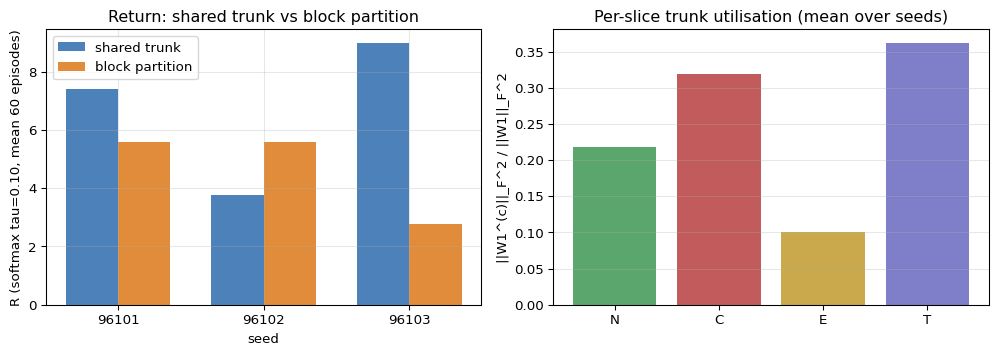

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))

seed_df = pd.DataFrame(rows).set_index("seed")
xs = np.arange(len(SEEDS))
w = 0.36
axes[0].bar(xs - w/2, seed_df["R_shared"], width=w, label="shared trunk", color="#4d81ba")
axes[0].bar(xs + w/2, seed_df["R_bp"],     width=w, label="block partition", color="#e08c3b")
axes[0].set_xticks(xs, [str(s) for s in SEEDS])
axes[0].set_xlabel("seed")
axes[0].set_ylabel("R (softmax tau=0.10, mean 60 episodes)")
axes[0].set_title("Return: shared trunk vs block partition")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

util_only = util_df.loc[SEEDS]
mean_util = util_only.mean()
axes[1].bar(list(mean_util.index), mean_util.values,
            color=["#5aa66d", "#c25b5b", "#c9a94b", "#7e7ec9"])
axes[1].set_ylabel("||W1^(c)||_F^2 / ||W1||_F^2")
axes[1].set_title("Per-slice trunk utilisation (mean over seeds)")
axes[1].grid(True, alpha=0.3, axis="y")

fig.tight_layout()
plt.show()


## 4. 결과 해석

**Return 관찰**. 실측치는 시드별로 극단적으로 갈렸다 — seed 96101 에서 shared 7.39 vs bp
5.58 (block partition 이 열위), 96102 에서 shared 3.78 vs bp 5.59 (block partition 이 우세),
96103 에서 shared 9.00 vs bp 2.75 (block partition 이 크게 열위). 세 시드 평균은
$R^{\text{shared}} = 6.72$, $R^{\text{bp}} = 4.64$, $\Delta_{\text{bp}} = -2.08$ 로 block
partition 이 **평균적으로는 후퇴**. 표준편차 4.04 로 시드 감수성이 매우 크다 —
$\Delta_{\text{bp}}$ 는 시드에 따라 부호가 뒤집힌다.

**Utilisation 관찰**. 학습 종료 시점 슬라이스별 $\|W_1^{(c)}\|_F^2 / \|W_1\|_F^2$ 는
평균적으로 **T (Twin, 0.363), C (Cramér, 0.319), N (Noisy, 0.218), E (EMA, 0.100)** 순.
초기화가 동일 median $\sigma_0$ 였음에도 학습이 EMA 슬라이스를 뚜렷하게 억제하고 (whitening
이 gradient 스케일 축소), Twin/Cramér 슬라이스가 dominant 로 자리잡음. **EMA 는 block
partition 하에서 실질적 표현력을 거의 잃음** — 이는 EMA 성분이 공유 트렁크 상에서
whitening 을 통해 다른 성분의 gradient 를 노멀라이즈해 주는 *조력자* 역할이었을 가능성을
시사.

> **결론**: block partition 은 **평균적으로 R 을 오히려 후퇴시킴** ($\Delta_{\text{bp}}
> = -2.08$), 표현력 절감이 gradient 간섭 제거의 이득을 능가한다. 게다가 시드 감수성이
> 매우 커서 (std 4.04) 결과 자체가 불안정. EMA 슬라이스가 utilisation 10% 로 사실상
> dormant 인 점은 **성분별 disjoint capacity 배분이 최적이 아님** 을 보여준다 — 성분마다
> 실제 필요한 폭이 다른데 강제로 균등 분할했기 때문.

다음 P2 에서는 Day 95 P2 의 wider-trunk near-uniform 수렴이 **더 어려운 chain
($p_{\text{train}}=0.20$) + 5 슬립 배포** 에서도 유지되는지, Cramér vs KL 순위가
재출현하는지 확인한다.
